# Описательная статистика


**Исполнители (ФИО):** Липунцов Антон Юрьевич

---

Здравствуйте! В этом практикуме вам предстоит познакомиться с базовыми действиями при работе с данными: генерация данных, их визуализация, расчет простых статистик.

## Задача 1

Для генерации данных используются numpy.random из numpy: библиотека для алгебраичесикх оппераций и scipy.stats: библиотека для работы с инструментами статистики.

Для начала, сгенерируйте реализацию выборки из равномерного распределения $R[2; 4]$ размером $50$ удобным вам способом

In [26]:
import numpy as np

N = 50

sample_uni = np.random.uniform(2, 4, N)
sample_uni[:10]

array([3.92091511, 3.18427317, 2.3894487 , 2.54589922, 3.96184358,
       3.223538  , 3.91900379, 2.78789888, 3.07977888, 2.82455635])

Сгенерируйте ещё две выборки: из экспоненциального распреленения $Exp(2)$ и нормального распределения $\mathcal{N}(1, 4)$

In [27]:
sample_exp = np.random.exponential(1/2, N)
sample_norm = np.random.normal(1, 2, N)

Теперь посчитайте некоторые простые статистики для данных выборок: выборочное среднее, стандартное отклонение и медиану. Сравните свои результаты со встроенными функциями

In [28]:
from scipy import stats

def calculate_stats(sample):
    n = len(sample)
    mean = sum(sample)/n
    dev = (sum([(x - mean)**2 for x in sample]) / (n-1))**0.5
    sorted_sample = np.sort(sample)
    if n % 2 == 1:
        med = sorted_sample[n // 2]
    else:
        med = (sorted_sample[n // 2 - 1] + sorted_sample[n // 2]) / 2
    return mean, dev, med

mean_uni = np.mean(sample_uni)
mean_exp = np.mean(sample_exp)
mean_norm = np.mean(sample_norm)

dev_uni = np.std(sample_uni)
dev_exp = np.std(sample_exp)
dev_norm = np.std(sample_norm)

med_uni = np.median(sample_uni)
med_exp = np.median(sample_exp)
med_norm = np.median(sample_norm)

print(calculate_stats(sample_uni))
print(f"Uniform(2, 4): среднее {mean_uni}, отклонение {dev_uni},  медиана {med_uni}\n\n")

print(calculate_stats(sample_exp))
print(f"Exponential(2): среднее {mean_exp}, отклонение {dev_exp},  медиана {med_exp}\n\n")

print(calculate_stats(sample_norm))
print(f"Normal(1, 4): среднее {mean_norm}, отклонение {dev_norm},  медиана {med_norm}\n\n")

(np.float64(3.1182734682520596), np.float64(0.5509429456457057), np.float64(3.081204473534279))
Uniform(2, 4): среднее 3.1182734682520588, отклонение 0.5454056900781579,  медиана 3.081204473534279


(np.float64(0.5969073336070333), np.float64(0.46844660443345054), np.float64(0.46952123893009196))
Exponential(2): среднее 0.5969073336070331, отклонение 0.46373847886618724,  медиана 0.46952123893009196


(np.float64(0.9099769910300105), np.float64(2.206123681782031), np.float64(0.8583323415111288))
Normal(1, 4): среднее 0.9099769910300104, отклонение 2.18395102173403,  медиана 0.8583323415111288




**Вопрос:** совпали ли посчитанные статистики с аналогичными параметрами этих распределений?

Совпали не совсем точно из-за небольших размеров выборок (50)

Если выборка одномерная, ее удобно визуализировать при помощи гистограммы

Визуализируйте свои выборки в одной группе графиков

Text(0.5, 1.0, 'Normal(1, 4)')

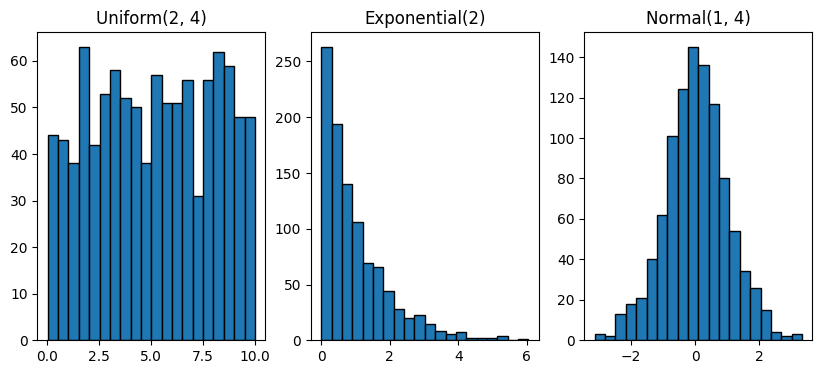

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.hist(sample_uni, bins=20, edgecolor='black')
plt.title('Uniform(2, 4)')

plt.subplot(1, 3, 2)
plt.hist(sample_exp, bins=20, edgecolor='black')
plt.title('Exponential(2)')

plt.subplot(1, 3, 3)
plt.hist(sample_norm, bins=20, edgecolor='black')
plt.title('Normal(1, 4)')

Для каждой выборки добавьте на график оценку плотности распределения и истинную плотность распределения

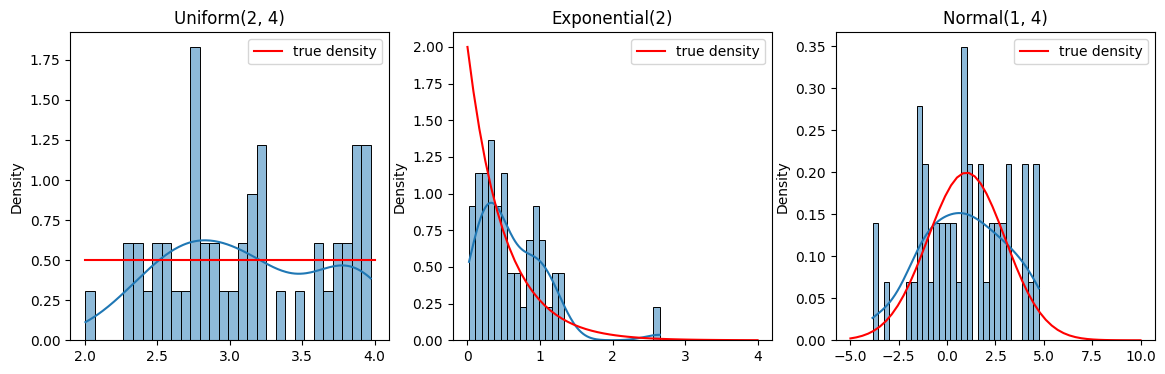

In [30]:
import seaborn as sb
import scipy

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sb.histplot(sample_uni, kde=True, bins=30, stat='density')
x_plot = np.linspace(2, 4, N)
pdf_uni = scipy.stats.uniform.pdf(x_plot, loc=2, scale=2)
plt.plot(x_plot, pdf_uni, color="r", label='true density')
plt.title('Uniform(2, 4)')
plt.legend()

plt.subplot(1, 3, 2)
sb.histplot(sample_exp, kde=True, bins=30, stat='density')
x_plot = np.linspace(0, 4, N)
pdf_exp = scipy.stats.expon.pdf(x_plot, scale=1/2)
plt.plot(x_plot, pdf_exp, color="r", label='true density')
plt.title('Exponential(2)')
plt.legend()

plt.subplot(1, 3, 3)
sb.histplot(sample_norm, kde=True, bins=30, stat='density')
x_plot = np.linspace(-5, 10, N)
pdf_norm = scipy.stats.norm.pdf(x_plot, loc=1, scale=2)
plt.plot(x_plot, pdf_norm, color="r", label='true density')
plt.title('Normal(1, 4)')
plt.legend()

**Вопрос:** Что влияет на оценку плотности? Насколько оценка плотности совпадает с истинной?

На оценку плотности влияет количество результатов в окрестности конкретного значения и размер выборки. При нашем небольшом размере оценка не сильно отличается от истиной плотности.

Для каждой выборки дополнительно добавьте на график оценку функции распределения и истинную функцию распределения

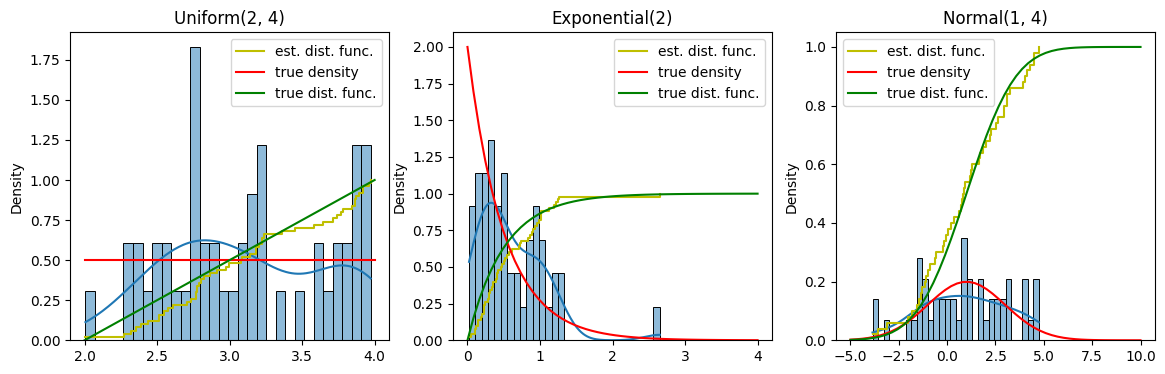

In [31]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sb.histplot(sample_uni, kde=True, bins=30, stat='density')
x_sort = np.sort(sample_uni)
y = np.arange(1, N + 1) / N
plt.step(x_sort, y, where='post', label='est. dist. func.', color='y')
x_plot = np.linspace(2, 4, N)
pdf_uni = scipy.stats.uniform.pdf(x_plot, loc=2, scale=2)
cdf_uni = scipy.stats.uniform.cdf(x_plot, loc=2, scale=2)
plt.plot(x_plot, pdf_uni, color="r", label='true density')
plt.plot(x_plot, cdf_uni, color="g", label='true dist. func.')
plt.title('Uniform(2, 4)')
plt.legend()

plt.subplot(1, 3, 2)
sb.histplot(sample_exp, kde=True, bins=30, stat='density')
x_sort = np.sort(sample_exp)
y = np.arange(1, N + 1) / N
plt.step(x_sort, y, where='post', label='est. dist. func.', color='y')
x_plot = np.linspace(0, 4, N)
pdf_exp = scipy.stats.expon.pdf(x_plot, scale=1/2)
cdf_exp = scipy.stats.expon.cdf(x_plot, scale=1/2)
plt.plot(x_plot, pdf_exp, color="r", label='true density')
plt.plot(x_plot, cdf_exp, color="g", label='true dist. func.')
plt.title('Exponential(2)')
plt.legend()

plt.subplot(1, 3, 3)
sb.histplot(sample_norm, kde=True, bins=30, stat='density')
x_sort = np.sort(sample_norm)
y = np.arange(1, N + 1) / N
plt.step(x_sort, y, where='post', label='est. dist. func.', color='y')
x_plot = np.linspace(-5, 10, N)
pdf_norm = scipy.stats.norm.pdf(x_plot, loc=1, scale=2)
cdf_norm = scipy.stats.norm.cdf(x_plot, loc=1, scale=2)
plt.plot(x_plot, pdf_norm, color="r", label='true density')
plt.plot(x_plot, cdf_norm, color="g", label='true dist. func.')
plt.title('Normal(1, 4)')
plt.legend()

**Вопрос:** Что влияет на оценку функции распределения? Насколько оценка функции распределения совпадает с истинной?

Размер выборки; оценка не сильно отличается от истинной функции распределения

Изменяйте параметры распределения, размер выборки и параметры гистограммы,  и визуализируйте несколько результатов

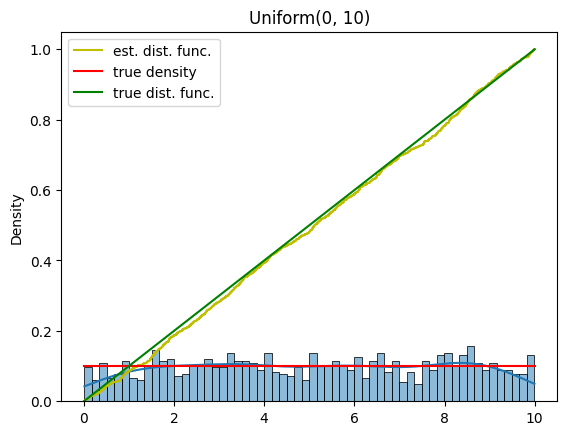

In [32]:
N = 1000
sample_uni = np.random.uniform(0, 10, N)

sb.histplot(sample_uni, kde=True, bins=60, stat='density')
x_sort = np.sort(sample_uni)
y = np.arange(1, N + 1) / N
plt.step(x_sort, y, where='post', label='est. dist. func.', color='y')
x_plot = np.linspace(0, 10, N)
pdf_uni = scipy.stats.uniform.pdf(x_plot, loc=0, scale=10)
cdf_uni = scipy.stats.uniform.cdf(x_plot, loc=0, scale=10)
plt.plot(x_plot, pdf_uni, color="r", label='true density')
plt.plot(x_plot, cdf_uni, color="g", label='true dist. func.')
plt.title('Uniform(0, 10)')
plt.legend()

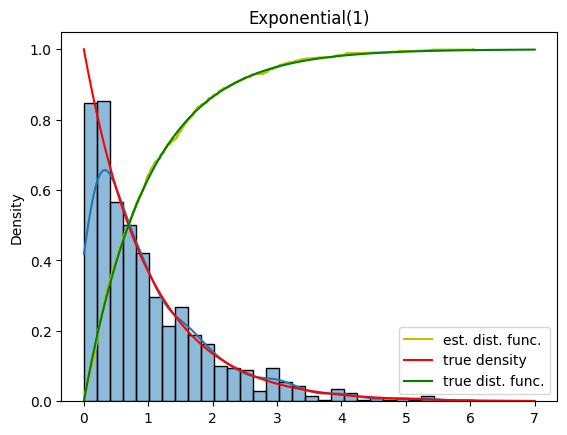

In [33]:
sample_exp = np.random.exponential(1, N)

sb.histplot(sample_exp, kde=True, bins=30, stat='density')
x_sort = np.sort(sample_exp)
y = np.arange(1, N + 1) / N
plt.step(x_sort, y, where='post', label='est. dist. func.', color='y')
x_plot = np.linspace(0, 7, N)
pdf_exp = scipy.stats.expon.pdf(x_plot, scale=1)
cdf_exp = scipy.stats.expon.cdf(x_plot, scale=1)
plt.plot(x_plot, pdf_exp, color="r", label='true density')
plt.plot(x_plot, cdf_exp, color="g", label='true dist. func.')
plt.title('Exponential(1)')
plt.legend()

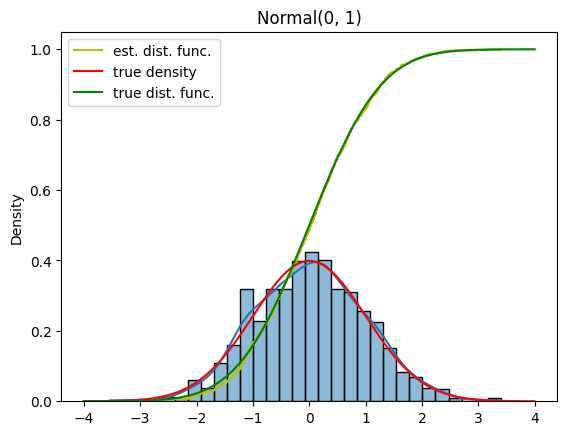

In [34]:
sample_norm = np.random.normal(0, 1, N)

sb.histplot(sample_norm, kde=True, bins=30, stat='density')
x_sort = np.sort(sample_norm)
y = np.arange(1, N + 1) / N
plt.step(x_sort, y, where='post', label='est. dist. func.', color='y')
x_plot = np.linspace(-4, 4, N)
pdf_norm = scipy.stats.norm.pdf(x_plot, loc=0, scale=1)
cdf_norm = scipy.stats.norm.cdf(x_plot, loc=0, scale=1)
plt.plot(x_plot, pdf_norm, color="r", label='true density')
plt.plot(x_plot, cdf_norm, color="g", label='true dist. func.')
plt.title('Normal(0, 1)')
plt.legend()

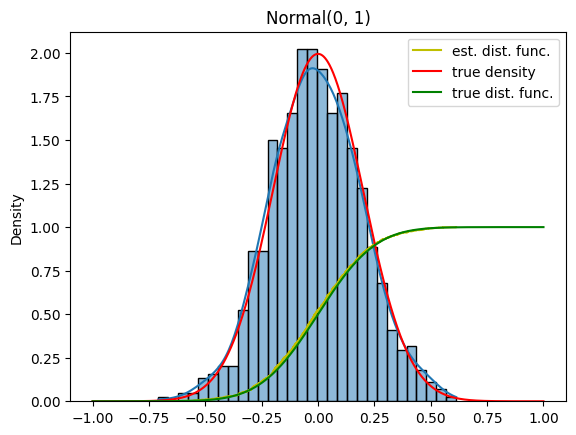

In [35]:
sample_norm = np.random.normal(0, 1/5, N)

sb.histplot(sample_norm, kde=True, bins=30, stat='density')
x_sort = np.sort(sample_norm)
y = np.arange(1, N + 1) / N
plt.step(x_sort, y, where='post', label='est. dist. func.', color='y')
x_plot = np.linspace(-1, 1, N)
pdf_norm = scipy.stats.norm.pdf(x_plot, loc=0, scale=1/5)
cdf_norm = scipy.stats.norm.cdf(x_plot, loc=0, scale=1/5)
plt.plot(x_plot, pdf_norm, color="r", label='true density')
plt.plot(x_plot, cdf_norm, color="g", label='true dist. func.')
plt.title('Normal(0, 1)')
plt.legend()

**Вопрос:** Как параметры влияют на гистограмму? На оценки функции распределения и плотности?

Размер выборки делает точнее оценки, параметры выборок двигают их или растягивают

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Задача 2

Для работы с файлами и таблицами удобно использовать библиотеку pandas. Изучите описание к файлу [*titanic.csv*](https://www.kaggle.com/competitions/titanic/data) и загрузите его в качестве датафрейма

In [37]:
import pandas as pd

df = pd.read_csv("titanic.csv")

Выведите общую информацию о датафрейме

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Выведите размер датафрейма и название колонок

In [39]:
print(df.columns.to_list())
print(df.shape)

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
(891, 12)


**Вопрос:** Сколько всего строк и столбцов в датафрейме? Как называется пятая колонка?

891 строк, 12 столбцов, Sex

Выведите подтаблицу, содержащую информацию о выживших пассажирах второго класса

In [40]:
survived_second_class = df[(df['Survived'] == 1) & (df['Pclass'] == 2)]
print(len(survived_second_class))
survived_second_class.head()

87


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C


**Вопрос:** Сколько из выживших пассажиров второго класса были старше 19 лет?

In [41]:
len(df[(df['Survived'] == 1) & (df['Pclass'] == 2) & (df['Age'] > 19)])

57

57

Посчитайте среднюю и медианную стоимость билетов по классам. Визуализируйте стоимость билетов по классам при помощи диаграммы размаха (ящик с усами)

Средняя стоимость по классам:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
Медианная стоимость по классам:
Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64


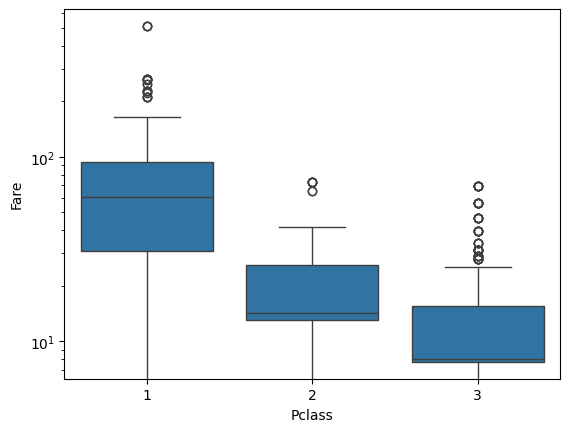

In [42]:
print("Средняя стоимость по классам:")
print(df.groupby('Pclass')['Fare'].mean())

print("Медианная стоимость по классам:")
print(df.groupby('Pclass')['Fare'].median())

sb.boxplot(x='Pclass', y='Fare', data=df)
plt.yscale('log')

**Вопрос:** Соответствуют ли цены билетов разделению на классы?

Да, по анализу цен видно, что чем выше класс, тем больше стоимость

Сделайте таблицу из числа выживших пассажиров, где столбцы - номер класса, строки - мужчины, женщины, дети

In [43]:
df.loc[df['Age'] < 18, 'Category'] = 'Ребенок'
df.loc[(df['Sex'] == 'male') & (df['Age'] >= 18), 'Category'] = 'Мужчина'
df.loc[(df['Sex'] == 'female') & (df['Age'] >= 18), 'Category'] = 'Женщина'

survival_table = pd.crosstab(index=df['Category'], columns=df['Pclass'], values=df['Survived'], aggfunc='sum')

survival_table

Pclass,1,2,3
Category,,,
Женщина,75,56,28
Мужчина,36,6,28
Ребенок,11,21,29


**Вопрос:** В каком классе была наибольшая выживаемость? В каком наименьшая? Среди кого?

In [51]:
survival_table.sum(axis=0)

,0
Pclass,
1,122
2,83
3,85


Видно, что больше выжило женщин в первом классе, меньше всего - мужчин во втором

Постройте диаграмму рассения для возраста и стоимости билета. Задайте цветом класс, а формой точек - пол

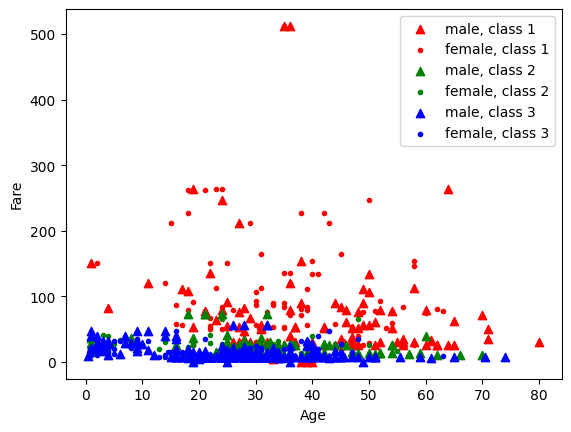

In [57]:
markers = {'male': '^', 'female': '.'}
colors = {1: 'red', 2: 'green', 3: 'blue'}

for pclass in [1, 2, 3]:
    for sex in ['male', 'female']:
        subset = df[(df['Pclass'] == pclass) & (df['Sex'] == sex)]
        plt.scatter(subset['Age'], subset['Fare'], c=colors[pclass], marker=markers[sex], label=f'{sex}, class {pclass}')

plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend()
plt.show()

**Вопрос:** Группируются ли данные по какому-то из признаков?

Данные сильнее всего группируются по цене билета

## Задача 3

Смоделируйте 1000 реализаций с.в. $X\sim Cauchy(0, 1)$ и с.в. $Y\sim\mathcal{N}(0, 1)$. Сравните полученные выборки

(np.float64(0.8363289735139354), np.float64(19.360447441197728), np.float64(-0.0026576589033588016))
(np.float64(-0.03324549763562017), np.float64(0.9811816122267407), np.float64(-0.014039442268403207))


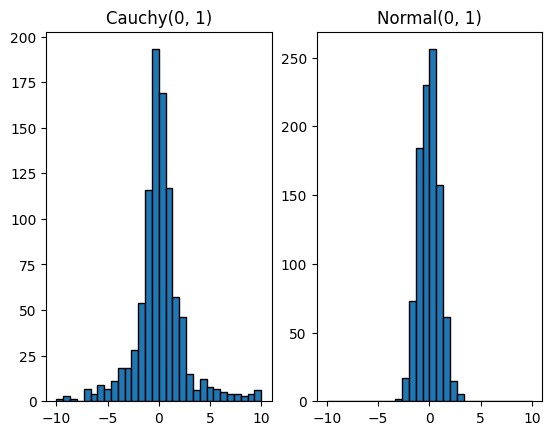

In [75]:
N = 1000

sample_cauchy = stats.cauchy.rvs(loc=0, scale=1, size=N)
sample_norm = np.random.normal(0, 1, N)

plt.subplot(1, 2, 1)
plt.hist(sample_cauchy, bins=30, range=[-10, 10], edgecolor='black')
plt.title('Cauchy(0, 1)')

plt.subplot(1, 2, 2)
plt.hist(sample_norm, bins=30, range=[-10, 10], edgecolor='black')
plt.title('Normal(0, 1)')

print(calculate_stats(sample_cauchy))

print(calculate_stats(sample_norm))

**Вопрос:** Выборки оказались похожи?

Нет, у распределения Коши больше дисперсия, нормальное распределение больше сконцентрировано в центре

Сгенерируйте выборки размера 50 для независимых с.в. $X,Y\sim\mathcal{N}(1,2)$. Постройте ядерную оценку плотности для двумерного случайного вектора $(X+Y,X-Y)$. Попробуйте изменять размер выборки

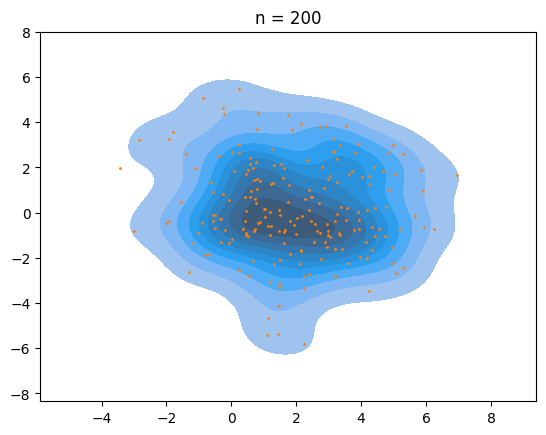

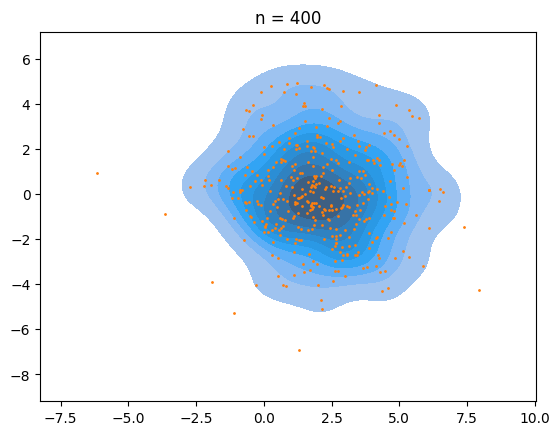

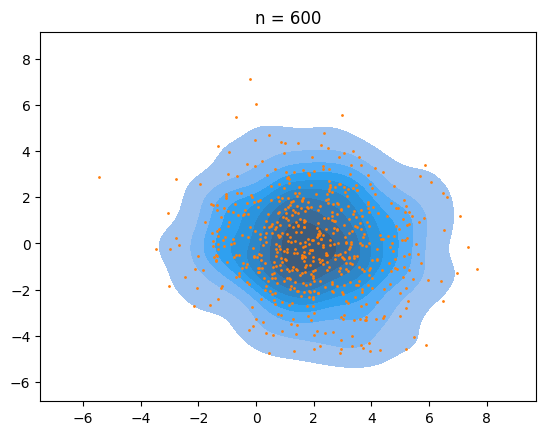

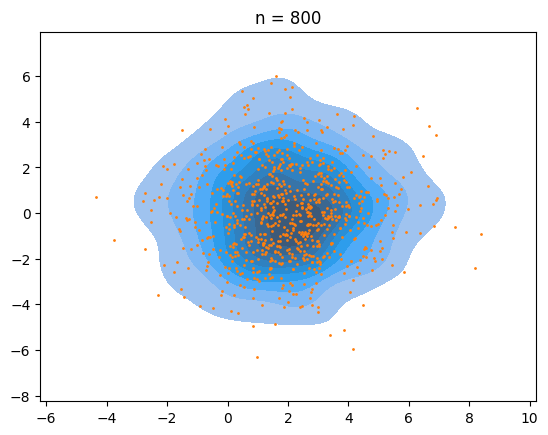

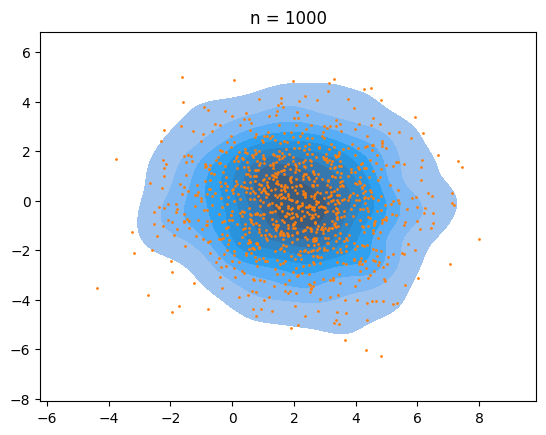

In [105]:
for n in range(200, 1001, 200):
    x = np.random.normal(1, np.sqrt(2), n)
    y = np.random.normal(1, np.sqrt(2), n)

    data = np.vstack([x+y, x-y]).T

    sb.kdeplot(x=data[:, 0], y=data[:, 1], fill=True)
    plt.scatter(data[:, 0], data[:, 1], s=1)
    plt.title(f'n = {n}')
    plt.show()

<Axes: >

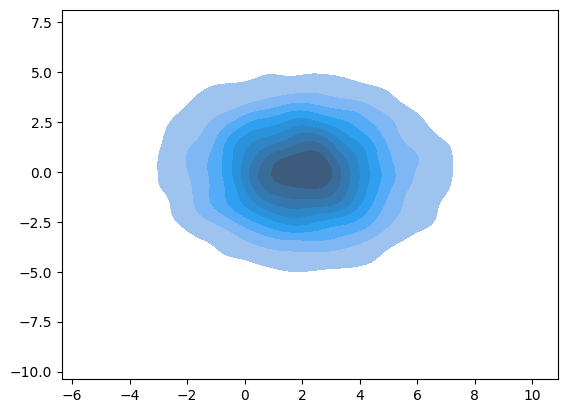

In [111]:
mean, cov = [2, 0], [(4, 0), (0, 4)]
x, y = np.random.multivariate_normal(mean, cov, size=5000).T
sb.kdeplot(x=x, y=y, fill=True)

**Вопрос:** При каком размере выборки ядерная оценка плотности начинает совпадать с истинной плотностью?

При размере выборки в 400 значений двумерный график похож на график истинной плотности